# 1. B41 Data Preparation

The raw MTA data comes as four monthly CSV files covering June, August, October, and December 2017. Before any modeling can happen, the data needs to be cleaned and aggregated into a form suitable for time series prediction.

The goal of this notebook is to go from roughly 350,000 individual GPS bus observations down to a time series of 30-minute route-level snapshots. Each row in the output represents one half-hour window and summarizes how delayed the B41 route was during that period.

The output is `B41_aggregated_30min.csv`, with one row per 30-minute window and columns: `timestamp`, `mean_delay`, `median_delay`, `std_delay`, `n_obs`, `pct_disrupted`, `month`.

In [6]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False})

RAW_FILES = [
    ('Jun', 'mta_1706.csv'),
    ('Aug', 'mta_1708.csv'),
    ('Oct', 'mta_1710.csv'),
    ('Dec', 'mta_1712.csv'),
]
ROUTE            = 'B41'
DISRUPTION_THR   = 10      # minutes — a bus is 'disrupted' if delay > 10 minutes
DELAY_CLIP_LOW   = -10     # clip extreme early arrivals
DELAY_CLIP_HIGH  = 60      # clip impossible large delays (data artefacts)
MIN_OBS_PER_WIN  = 3       # drop windows with fewer than this
OUTPUT_PATH      = 'B41_aggregated_30min.csv'

## Loading and Computing Delay

Each raw file is around 1.3 GB, so we load one month at a time and filter to B41 immediately to keep memory usage manageable.

Computing the delay turned out to be less straightforward than expected. The scheduled arrival times in the MTA data use a transit convention where service running past midnight is recorded as `24:xx:xx` or `25:xx:xx` rather than rolling over to the next calendar day. We handle this by normalizing hour 24 to `00:xx:xx` and discarding anything beyond that as corrupted. The actual scheduled datetime is then reconstructed by finding the calendar date closest to the observed GPS timestamp, which correctly handles buses that cross midnight.

Delay is computed as ExpectedArrivalTime minus the reconstructed scheduled time, in minutes. To remove obvious data errors we clip delays to the range [-10, 60] minutes — values outside this range are almost certainly recording artifacts rather than real delays.

In [7]:
def fix_scheduled_time(time_str):
    """Normalise transit time strings; return None for corrupt rows."""
    time_str = str(time_str).strip()
    if re.match(r'^\d{2}:\d{2}:\d{2}$', time_str):
        hour = int(time_str.split(':')[0])
        if hour == 24:
            return f"00:{time_str[3:]}"
        elif hour < 24:
            return time_str
    return None


def load_and_prepare(month_label, filepath):
    print(f'Loading {filepath} ...')
    df = pd.read_csv(filepath, on_bad_lines='skip')

    # Filter to B41 only — discard all other lines immediately
    df = df[df['PublishedLineName'] == ROUTE].copy()
    print(f'  B41 rows: {len(df):,}')

    # Fix ScheduledArrivalTime
    df['ScheduledArrivalTime'] = df['ScheduledArrivalTime'].astype(str).str.strip()
    df['valid_time'] = df['ScheduledArrivalTime'].apply(fix_scheduled_time)
    df = df[df['valid_time'].notna()].copy()
    df['ScheduledArrivalTime'] = df['valid_time']
    df.drop(columns='valid_time', inplace=True)

    # Parse datetimes
    df['RecordedAtTime']      = pd.to_datetime(df['RecordedAtTime'],      errors='coerce')
    df['ExpectedArrivalTime'] = pd.to_datetime(df['ExpectedArrivalTime'], errors='coerce')
    df = df[df['RecordedAtTime'].notna() & df['ExpectedArrivalTime'].notna()].copy()

    # Reconstruct Scheduled_dt (handles midnight crossover)
    sched_time      = pd.to_datetime(df['ScheduledArrivalTime'], format='%H:%M:%S').dt.time
    exp_date_str    = df['ExpectedArrivalTime'].dt.date.astype(str)
    candidate_same  = pd.to_datetime(exp_date_str + ' ' + sched_time.astype(str))
    candidate_prev  = candidate_same - pd.Timedelta(days=1)
    diff_same       = (df['ExpectedArrivalTime'] - candidate_same).abs()
    diff_prev       = (df['ExpectedArrivalTime'] - candidate_prev).abs()
    df['Scheduled_dt'] = candidate_same.where(diff_same <= diff_prev, candidate_prev)

    # Delay
    df['delay_minutes'] = (
        (df['ExpectedArrivalTime'] - df['Scheduled_dt']).dt.total_seconds() / 60
    )

    # Clip to remove data artefacts
    df['delay_minutes'] = df['delay_minutes'].clip(DELAY_CLIP_LOW, DELAY_CLIP_HIGH)

    df['month'] = month_label
    print(f'  After cleaning: {len(df):,} rows | delay mean={df["delay_minutes"].mean():.1f} min')
    return df[['RecordedAtTime', 'delay_minutes', 'month']]


monthly_dfs = [load_and_prepare(label, path) for label, path in RAW_FILES]
raw = pd.concat(monthly_dfs, ignore_index=True)

print(f'\nCombined B41 rows: {len(raw):,}')
print(raw.groupby('month')['delay_minutes'].describe().round(2))

Loading mta_1706.csv ...
  B41 rows: 101,068
  After cleaning: 91,776 rows | delay mean=9.9 min
Loading mta_1708.csv ...
  B41 rows: 94,490
  After cleaning: 85,003 rows | delay mean=7.1 min
Loading mta_1710.csv ...
  B41 rows: 102,190
  After cleaning: 89,319 rows | delay mean=8.8 min
Loading mta_1712.csv ...
  B41 rows: 98,069
  After cleaning: 81,955 rows | delay mean=9.2 min

Combined B41 rows: 348,053
         count  mean    std   min   25%   50%    75%   max
month                                                     
Aug    85003.0  7.14   9.77 -10.0  0.90  4.52  10.67  60.0
Dec    81955.0  9.16  11.86 -10.0  1.32  5.70  13.50  60.0
Jun    91776.0  9.87  12.48 -10.0  1.58  5.98  14.23  60.0
Oct    89319.0  8.82  11.05 -10.0  1.50  5.70  13.07  60.0


## Aggregating to 30-Minute Windows

We group all observations into 30-minute bins by flooring each recorded timestamp to the nearest half-hour. The 30-minute granularity is a deliberate tradeoff: fine enough to capture how delays evolve through the day (morning rush, midday, evening rush), but coarse enough that each window contains enough bus observations to compute a meaningful average.

For each window we compute five summary statistics: mean delay, median delay, standard deviation, observation count, and the fraction of buses with delay above 10 minutes (`pct_disrupted`). The mean delay alone can be misleading if one or two outlier buses pull the average up. `pct_disrupted` tells us whether delays were widespread across most of the fleet or concentrated in just a few vehicles, which is a meaningfully different situation.

Windows with fewer than 3 observations are dropped. These are mostly overnight slots where only one or two buses are active and the computed average is not representative of route conditions.

In [8]:
raw['window'] = raw['RecordedAtTime'].dt.floor('30min')
raw['is_disrupted'] = (raw['delay_minutes'] > DISRUPTION_THR).astype(float)

agg = (
    raw.groupby(['window', 'month'])
    .agg(
        mean_delay    = ('delay_minutes', 'mean'),
        median_delay  = ('delay_minutes', 'median'),
        std_delay     = ('delay_minutes', 'std'),
        n_obs         = ('delay_minutes', 'count'),
        pct_disrupted = ('is_disrupted',  'mean'),
    )
    .reset_index()
    .rename(columns={'window': 'timestamp'})
)

# Drop sparse overnight windows
before = len(agg)
agg = agg[agg['n_obs'] >= MIN_OBS_PER_WIN].copy()
print(f'Windows before/after sparse filter: {before:,} → {len(agg):,}')
print(f'Windows per month:')
print(agg.groupby('month')['timestamp'].count())

Windows before/after sparse filter: 5,759 → 5,728
Windows per month:
month
Aug    1357
Dec    1463
Jun    1437
Oct    1471
Name: timestamp, dtype: int64


## Validation

The plots below show the delay distribution per month, average delay by hour of day, disruption rate by hour, and the distribution of observations per window. We expect higher delays during morning and evening rush hours and a clear drop overnight. We also expect June and December to show more disruptions than August, which tends to be the quietest month.

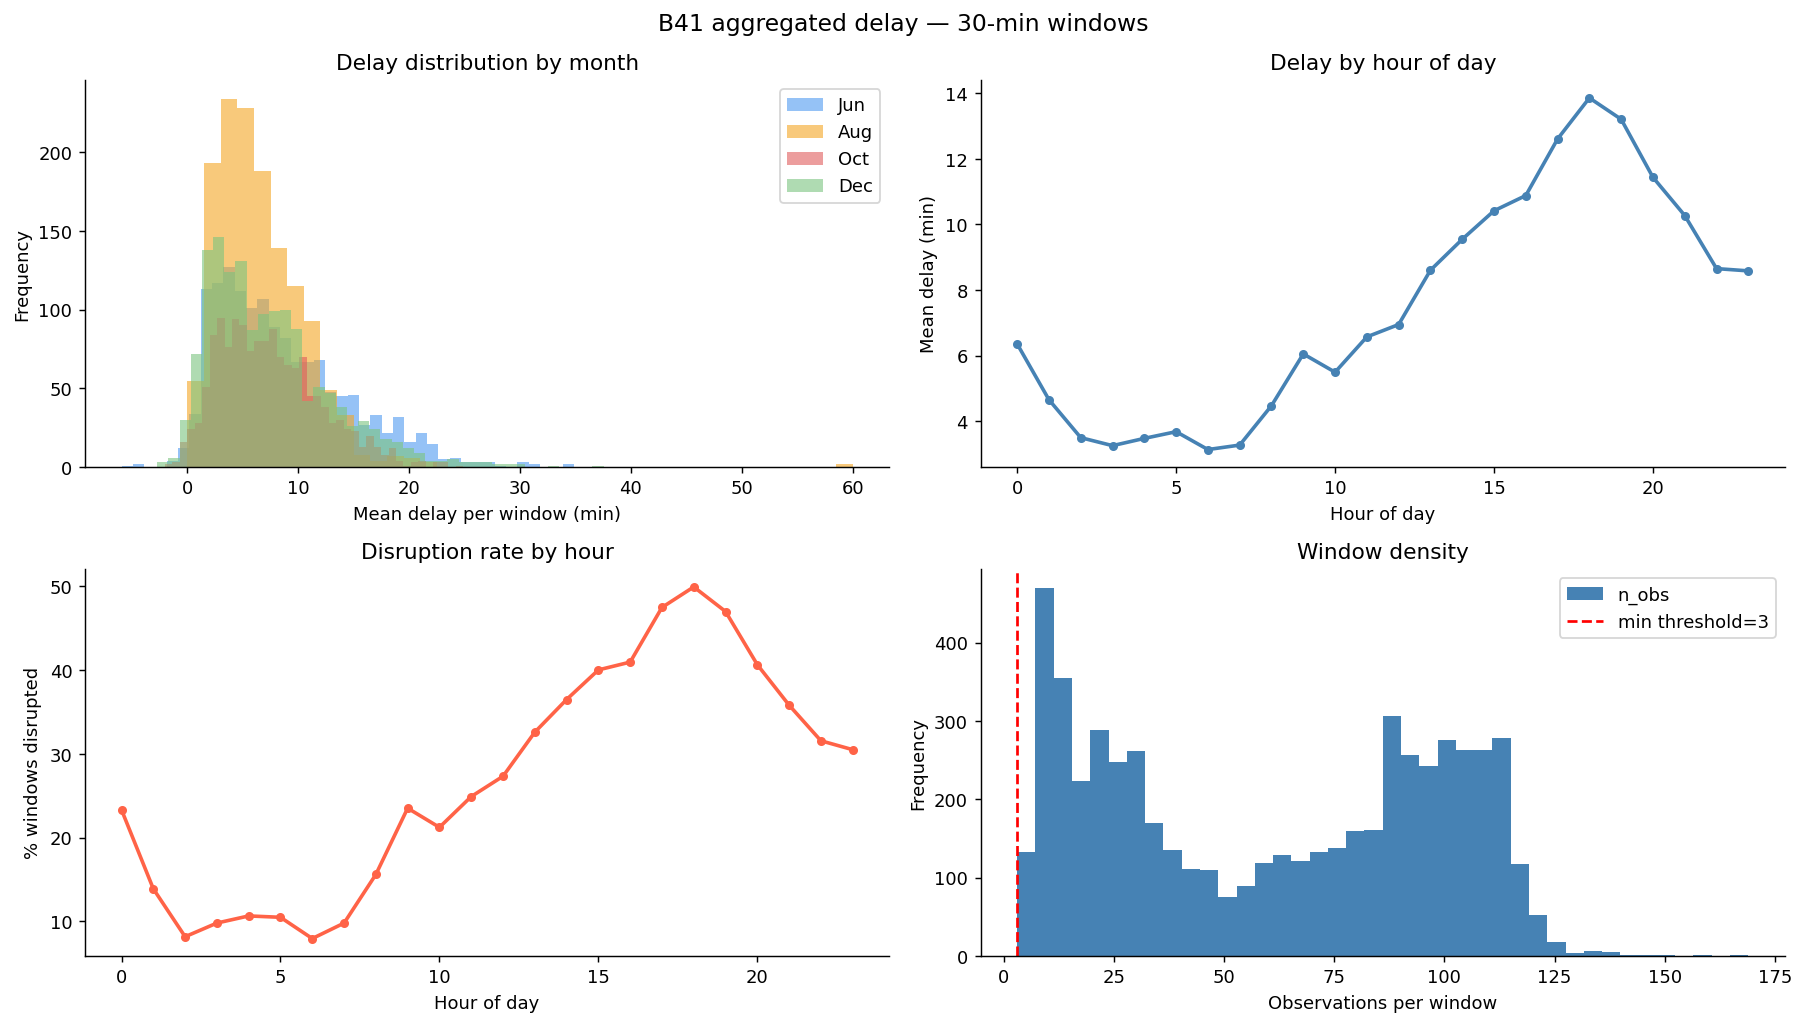

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('B41 aggregated delay — 30-min windows', fontsize=13)

month_order = ['Jun', 'Aug', 'Oct', 'Dec']
colors      = {'Jun': '#4e9af1', 'Aug': '#f4a623', 'Oct': '#e05c5c', 'Dec': '#7bc47f'}

# 1. Distribution of mean_delay per month
ax = axes[0, 0]
for m in month_order:
    subset = agg[agg['month'] == m]['mean_delay']
    subset.plot.hist(bins=40, alpha=0.6, label=m, color=colors[m], ax=ax)
ax.set_xlabel('Mean delay per window (min)')
ax.set_title('Delay distribution by month')
ax.legend()

# 2. Average mean_delay by hour of day
ax = axes[0, 1]
agg['hour'] = agg['timestamp'].dt.hour
hourly = agg.groupby('hour')['mean_delay'].mean()
ax.plot(hourly.index, hourly.values, color='steelblue', linewidth=2, marker='o', markersize=4)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Mean delay (min)')
ax.set_title('Delay by hour of day')

# 3. Disruption rate by hour
ax = axes[1, 0]
hourly_dis = agg.groupby('hour')['pct_disrupted'].mean()
ax.plot(hourly_dis.index, hourly_dis.values * 100, color='tomato', linewidth=2, marker='o', markersize=4)
ax.set_xlabel('Hour of day')
ax.set_ylabel('% windows disrupted')
ax.set_title('Disruption rate by hour')

# 4. n_obs distribution
ax = axes[1, 1]
agg['n_obs'].plot.hist(bins=40, ax=ax, color='steelblue', edgecolor='none')
ax.axvline(MIN_OBS_PER_WIN, color='red', linestyle='--', label=f'min threshold={MIN_OBS_PER_WIN}')
ax.set_xlabel('Observations per window')
ax.set_title('Window density')
ax.legend()

plt.tight_layout()
plt.show()

agg.drop(columns='hour', inplace=True)

## Save

In [10]:
agg = agg.sort_values('timestamp').reset_index(drop=True)
agg.to_csv(OUTPUT_PATH, index=False)

print(f'Saved → {OUTPUT_PATH}')
print(f'Shape : {agg.shape}')
print(f'Columns: {list(agg.columns)}')
print(f'\nSample rows:')
agg.head(8)

Saved → B41_aggregated_30min.csv
Shape : (5728, 7)
Columns: ['timestamp', 'month', 'mean_delay', 'median_delay', 'std_delay', 'n_obs', 'pct_disrupted']

Sample rows:


,timestamp,month,mean_delay,median_delay,std_delay,n_obs,pct_disrupted
0,2017-06-01 00:00:00,Jun,5.888889,5.616667,5.319791,21,0.142857
1,2017-06-01 00:30:00,Jun,3.282456,3.366667,4.111158,19,0.000000
2,2017-06-01 01:00:00,Jun,2.075000,1.375000,3.171354,10,0.000000
3,2017-06-01 01:30:00,Jun,1.695833,0.725000,3.001755,8,0.000000
4,2017-06-01 02:00:00,Jun,0.837500,0.325000,3.044187,12,0.000000
5,2017-06-01 02:30:00,Jun,0.938889,0.883333,0.933482,9,0.000000
6,2017-06-01 03:00:00,Jun,0.878205,0.816667,1.556057,13,0.000000
7,2017-06-01 03:30:00,Jun,3.515476,1.150000,4.960948,14,0.142857
